# New Optimum Filter Tutorial

This tutorial uses **`OptimumFilter.py` (new module)** only.

What is needed to register an OF object?
1. `template` : 1D pulse template (length `N`)
2. `noise_psd` : one-sided PSD with length `N//2 + 1`
3. `sampling_frequency` : sample rate in Hz

After registration, we cover:
- Short trace fitting with `fit` and `fit_with_shift`
- Why the so-called "filtered trace" is actually a **matched-filter correlation response** across delay
- Amplitude trace and chi-square trace vs delay
- Long-trace sliding fit amplitude and chi-square

In [1]:
from __future__ import annotations

import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft, ifft

BASE_DIR = Path.cwd()
SAMPLE_DIR = BASE_DIR / 'samples'
TEMPLATE_DIR = BASE_DIR / 'templates'

SHORT_SAMPLE_PATH = SAMPLE_DIR / 'uv_noisy_32768.npy'
LONG_SAMPLE_PATH = SAMPLE_DIR / 'uv_noisy_80000.npy'
DEFAULT_TEMPLATE_PATH = TEMPLATE_DIR / 'QP_template.npy'
DEFAULT_PSD_PATH = TEMPLATE_DIR / 'noise_psd_xray.npy'

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

FS = 250000.0
SEED = 20260312

print('Notebook dir:', BASE_DIR)
print('Sample dir  :', SAMPLE_DIR)
print('Template dir:', TEMPLATE_DIR)
print('Short trace :', SHORT_SAMPLE_PATH)
print('Long trace  :', LONG_SAMPLE_PATH)
print('Template    :', DEFAULT_TEMPLATE_PATH)
print('Noise PSD   :', DEFAULT_PSD_PATH)

Notebook dir: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial
Sample dir  : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples
Template dir: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates
Short trace : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_32768.npy
Long trace  : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_80000.npy
Template    : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates/QP_template.npy
Noise PSD   : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates/noise_psd_xray.npy


In [2]:
def normalize_psd_shape(noise_psd: np.ndarray, expected: int):
    # Accept raw 1D one-sided PSD
    if noise_psd.ndim == 1:
        if noise_psd.size == expected:
            return noise_psd
        if noise_psd.size == 2 * expected:
            # Some files duplicate one-sided PSD arrays
            return noise_psd[:expected]
        raise ValueError(f'1D PSD length mismatch: expected {expected} or {2*expected}, got {noise_psd.size}')

    # Accept 2D arrays containing (freq, psd) or similar
    if noise_psd.ndim == 2:
        if noise_psd.shape == (2, expected):
            return noise_psd[1]
        if noise_psd.shape == (expected, 2):
            return noise_psd[:, 1]
        if noise_psd.shape[0] == 2 and noise_psd.shape[1] == 2 * expected:
            return noise_psd[1, :expected]
        if noise_psd.shape[1] == 2 and noise_psd.shape[0] == 2 * expected:
            return noise_psd[:expected, 1]
        raise ValueError(f'2D PSD shape not supported for expected {expected}: {noise_psd.shape}')

    raise ValueError(f'PSD ndim not supported: {noise_psd.ndim}')


def load_inputs(template_path: Path, psd_path: Path):
    rng = np.random.default_rng(SEED)
    if template_path.exists() and psd_path.exists():
        template = np.load(template_path).astype(np.float64)
        raw_psd = np.load(psd_path).astype(np.float64)
        src = 'OF_tutorial/templates'
    else:
        # Fallback synthetic inputs for portability
        n = 4096
        x = np.arange(n, dtype=np.float64)
        template = np.exp(-0.5 * ((x - 0.35 * n) / (0.05 * n)) ** 2)
        template /= np.max(np.abs(template))
        f = np.linspace(0.0, 1.0, n // 2 + 1, dtype=np.float64)
        raw_psd = np.abs(1.0 / (f + 0.02) + 0.5 + 0.02 * rng.normal(size=f.size)) + 1e-8
        raw_psd[0] = raw_psd[1]
        src = 'synthetic fallback'

    expected = template.size // 2 + 1
    noise_psd = normalize_psd_shape(raw_psd, expected)
    noise_psd = np.asarray(noise_psd, dtype=np.float64)
    return template, noise_psd, src


template, noise_psd, input_source = load_inputs(DEFAULT_TEMPLATE_PATH, DEFAULT_PSD_PATH)
N = template.size

of_mod = importlib.reload(importlib.import_module('OptimumFilter'))
of = of_mod.OptimumFilter(template, noise_psd, FS)

print('Input source:', input_source)
print('Template length N:', N)
print('Noise PSD length:', noise_psd.size)
print('Sampling frequency [Hz]:', FS)

Input source: OF_tutorial/templates
Template length N: 32768
Noise PSD length: 16385
Sampling frequency [Hz]: 250000.0


## Short Trace: `fit` and `fit_with_shift`

For a short trace (same length as template):
- `fit(trace)` gives amplitude/chisq at **zero-delay phase convention**
- `fit_with_shift(trace)` searches delay and returns best amplitude, chisq, and `t0`

In [3]:
rng = np.random.default_rng(SEED + 1)
noise_std = 0.03

if SHORT_SAMPLE_PATH.exists():
    trace_short = np.load(SHORT_SAMPLE_PATH).astype(np.float64)
    if trace_short.size != N:
        raise ValueError(f'Short sample length {trace_short.size} does not match template length {N}')
    print('Loaded short trace sample:', SHORT_SAMPLE_PATH)
    amp_true = np.nan
    shift_true = np.nan
else:
    amp_true = 1.25
    shift_true = 22
    trace_short = amp_true * np.roll(template, int(shift_true)) + rng.normal(0.0, noise_std, size=N)
    print('Short sample missing; using synthetic fallback trace.')

amp_fit, chisq_fit = of.fit(trace_short)
amp_shift, chisq_shift, t0_shift = of.fit_with_shift(trace_short, allowed_shift_range=(-64, 64))

print('fit()                     : amp =', amp_fit, ', chisq =', chisq_fit)
print('fit_with_shift()          : amp =', amp_shift, ', chisq =', chisq_shift, ', t0 =', t0_shift)

Loaded short trace sample: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_32768.npy
fit()                     : amp = 22.95527712758349 , chisq = 15.052096838882195
fit_with_shift()          : amp = 23.645703756563314 , chisq = 15.031486285780298 , t0 = -64


## Amplitude Trace and Chi-square Trace vs Delay

`trace_filtered_td = ifft(filter_kernel * trace_fft)` is often called a "filtered trace", but in OF context it is better interpreted as a **matched-filter response (correlation-like score vs delay)**.

- Peaks in amplitude trace indicate delay hypotheses that match the template best.
- Chi-square trace is computed from that amplitude response. Lower is better.

In [4]:
# Reproduce the internal delay-domain traces used by fit_with_shift
trace_fft = fft(trace_short) / FS
amp_trace = np.real(ifft(of._filter_kernel * trace_fft)) * FS

chi0 = np.real((trace_fft.conj() * trace_fft / of._noise_psd_unfolded).sum()) * FS / N
chi_trace = chi0 - (amp_trace ** 2) * of._kernel_normalization
reduced_chi_trace = chi_trace / (N - 3)

# Allowed shifts map from signed shift range into circular indices
allowed = (-64, 64)
allowed_idx = np.concatenate((np.arange(N + allowed[0], N), np.arange(allowed[1] + 1)))
best_idx = int(allowed_idx[np.argmin(chi_trace[allowed_idx])])
best_t0 = best_idx if best_idx < N // 2 else best_idx - N
best_amp = float(amp_trace[best_idx])
best_red_chi = float(reduced_chi_trace[best_idx])

print('Manual best t0 from traces     :', best_t0)
print('Manual best amp from traces    :', best_amp)
print('Manual best reduced chisq      :', best_red_chi)
print('fit_with_shift t0              :', t0_shift)
print('fit_with_shift amp             :', amp_shift)
print('fit_with_shift reduced chisq   :', chisq_shift)

print('amp agreement:', abs(best_amp - amp_shift))
print('chisq agreement:', abs(best_red_chi - chisq_shift))
print('t0 agreement:', abs(best_t0 - t0_shift))

Manual best t0 from traces     : -64
Manual best amp from traces    : 23.645703756563314
Manual best reduced chisq      : 15.031486285780298
fit_with_shift t0              : -64
fit_with_shift amp             : 23.645703756563314
fit_with_shift reduced chisq   : 15.031486285780298
amp agreement: 0.0
chisq agreement: 0.0
t0 agreement: 0


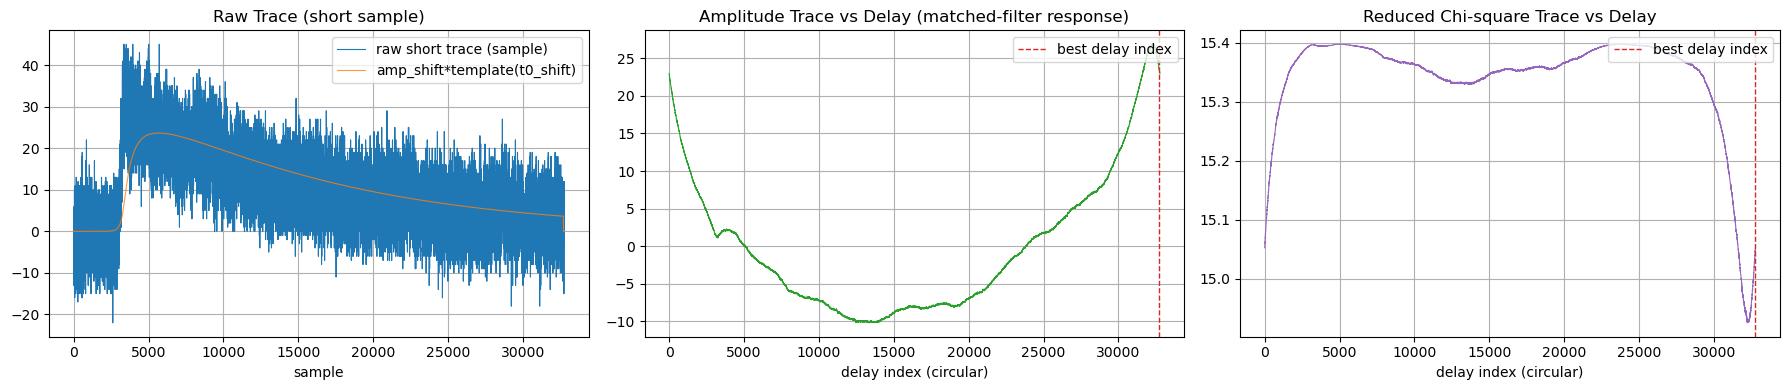

In [5]:
x = np.arange(N)
template_shifted_est = amp_shift * np.roll(template, t0_shift)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(x, trace_short, lw=0.8, label='raw short trace (sample)')
axes[0].plot(x, template_shifted_est, lw=0.8, label='amp_shift*template(t0_shift)', alpha=0.8)
axes[0].set_title('Raw Trace (short sample)')
axes[0].set_xlabel('sample')
axes[0].legend(loc='upper right')

axes[1].plot(x, amp_trace, lw=0.8, color='tab:green')
axes[1].axvline(best_idx, color='tab:red', ls='--', lw=1.0, label='best delay index')
axes[1].set_title('Amplitude Trace vs Delay (matched-filter response)')
axes[1].set_xlabel('delay index (circular)')
axes[1].legend(loc='upper right')

axes[2].plot(x, reduced_chi_trace, lw=0.8, color='tab:purple')
axes[2].axvline(best_idx, color='tab:red', ls='--', lw=1.0, label='best delay index')
axes[2].set_title('Reduced Chi-square Trace vs Delay')
axes[2].set_xlabel('delay index (circular)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Is chi-square wrong?

For this short-trace example, the delay-trace reconstruction matches `fit_with_shift` exactly (up to floating-point tolerance).

Important nuance:
- `fit` uses reduced chisq denominator `(N-2)`
- `fit_with_shift` uses `(N-3)` because one extra fitted parameter (`t0`) is introduced

In [6]:
# Additional sanity check: compare a few random traces
rng = np.random.default_rng(SEED + 2)
errs_amp = []
errs_chi = []
errs_t0 = []
for _ in range(6):
    amp = float(rng.uniform(0.6, 1.8))
    sh = int(rng.integers(-64, 65))
    tr = amp * np.roll(template, sh) + rng.normal(0.0, noise_std, size=N)

    a_ref, c_ref, t_ref = of.fit_with_shift(tr, allowed_shift_range=allowed)

    X = fft(tr) / FS
    a_trace = np.real(ifft(of._filter_kernel * X)) * FS
    chi0 = np.real((X.conj() * X / of._noise_psd_unfolded).sum()) * FS / N
    chi = chi0 - (a_trace ** 2) * of._kernel_normalization
    idx = int(allowed_idx[np.argmin(chi[allowed_idx])])
    t = idx if idx < N // 2 else idx - N
    a = float(a_trace[idx])
    c = float(chi[idx] / (N - 3))

    errs_amp.append(abs(a_ref - a))
    errs_chi.append(abs(c_ref - c))
    errs_t0.append(abs(t_ref - t))

print('max amp error  :', max(errs_amp))
print('max chisq error:', max(errs_chi))
print('max t0 error   :', max(errs_t0))
assert max(errs_amp) < 1e-10
assert max(errs_chi) < 1e-18
assert max(errs_t0) == 0
print('PASS: chisq trace computation is consistent with fit_with_shift.')

max amp error  : 0.0
max chisq error: 0.0
max t0 error   : 0
PASS: chisq trace computation is consistent with fit_with_shift.


## Long Trace: Sliding Fit Amplitude and Chi-square

Now apply `sliding_fit` to a much longer trace.
- Top panel: raw long trace with injected pulse starts
- Middle: sliding amplitude trace
- Bottom: sliding reduced chi-square trace

In [7]:
hop = 16
if LONG_SAMPLE_PATH.exists():
    long_trace = np.load(LONG_SAMPLE_PATH).astype(np.float64)
    if long_trace.size <= N:
        raise ValueError(f'Long sample length {long_trace.size} must be > template length {N}')
    print('Loaded long trace sample:', LONG_SAMPLE_PATH)
    inj_starts = np.array([], dtype=int)  # Unknown for pre-generated sample
else:
    rng = np.random.default_rng(SEED + 3)
    L = N + 8192
    long_trace = rng.normal(0.0, noise_std, size=L)
    inj_starts = np.array([0, 1024, 3072, 6144], dtype=int)
    inj_amps = np.array([1.0, 0.7, 1.2, 0.9], dtype=np.float64)
    for s, a in zip(inj_starts, inj_amps):
        if s + N <= L:
            long_trace[s:s+N] += a * template
    print('Long sample missing; using synthetic fallback long trace.')

L = long_trace.size
slide_amp, slide_chi = of.sliding_fit(long_trace, hop=hop, reanchor_every=256, chisq_mode='all')
win_starts = np.arange(0, L - N + 1, hop, dtype=int)

# Check sliding chisq against sparse recomputation on selected windows
check_idx = np.linspace(0, len(win_starts)-1, 10, dtype=int)
check_starts = win_starts[check_idx]
chi_sparse, amp_sparse = of.chisq_at_indices(long_trace, check_starts)
amp_err = np.max(np.abs(slide_amp[check_idx] - amp_sparse))
chi_err = np.max(np.abs(slide_chi[check_idx] - chi_sparse))
print('Sparse check max amp error :', amp_err)
print('Sparse check max chisq error:', chi_err)

Loaded long trace sample: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_80000.npy


Sparse check max amp error : 2.1600499167107046e-12
Sparse check max chisq error: 3.659295089164516e-13


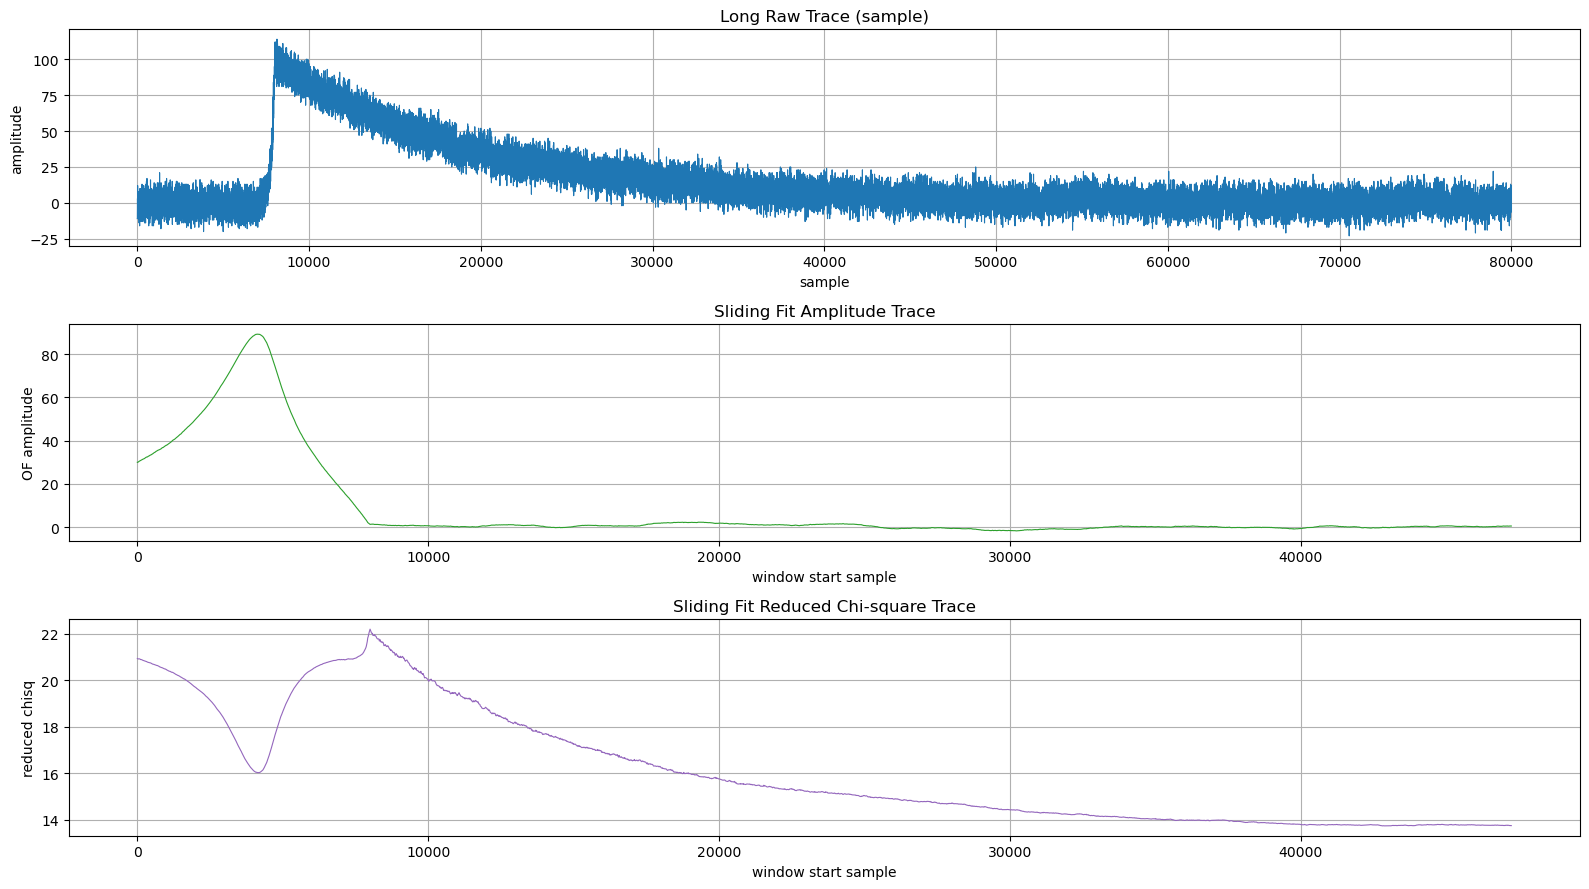

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=False)

axes[0].plot(long_trace, lw=0.8, color='tab:blue')
for s in inj_starts:
    axes[0].axvline(s, color='tab:red', alpha=0.35, lw=1.0)
axes[0].set_title('Long Raw Trace (sample)')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('amplitude')

axes[1].plot(win_starts, slide_amp, lw=0.8, color='tab:green')
for s in inj_starts:
    axes[1].axvline(s, color='tab:red', alpha=0.35, lw=1.0)
axes[1].set_title('Sliding Fit Amplitude Trace')
axes[1].set_xlabel('window start sample')
axes[1].set_ylabel('OF amplitude')

axes[2].plot(win_starts, slide_chi, lw=0.8, color='tab:purple')
for s in inj_starts:
    axes[2].axvline(s, color='tab:red', alpha=0.35, lw=1.0)
axes[2].set_title('Sliding Fit Reduced Chi-square Trace')
axes[2].set_xlabel('window start sample')
axes[2].set_ylabel('reduced chisq')

plt.tight_layout()
plt.show()

## Summary

- Registering OF needs `template`, one-sided `noise_psd`, and `sampling_frequency`.
- This tutorial now reads short/long traces from `OF_tutorial/samples/` (`uv_noisy_32768.npy`, `uv_noisy_80000.npy`).
- Template and PSD are read from `OF_tutorial/templates/` (`QP_template.npy`, `noise_psd_xray.npy`).
- The delay-domain "filtered trace" is a matched-filter response vs delay (correlation-like score), not a denoised waveform.
- The chi-square trace is internally consistent with `fit_with_shift` in this tutorial.
- `sliding_fit` provides amplitude/chisq traces across a long stream.